In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("../data/train.csv")
features = pd.read_csv("../data/features.csv")
stores = pd.read_csv("../data/stores.csv")
test = pd.read_csv("../data/test.csv")

In [ ]:
# Module 1 – Data Understanding

## Objective
Understand the structure of the Walmart dataset.

## Key Findings
- Target variable: Weekly_Sales
- 421,570 training records
- 4 datasets provided
- Date is currently stored as a string
- Features are spread across multiple tables and will need to be merged

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
train.shape

(421570, 5)

In [7]:
features.shape
stores.shape
test.shape

(115064, 4)

In [8]:
features.shape

(8190, 12)

In [9]:
stores.shape

(45, 3)

In [10]:
test.shape

(115064, 4)

In [11]:
train.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='str')

In [12]:
features.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='str')

In [13]:
stores.columns

Index(['Store', 'Type', 'Size'], dtype='str')

In [14]:
test.columns

Index(['Store', 'Dept', 'Date', 'IsHoliday'], dtype='str')

In [15]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


In [16]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   Store      115064 non-null  int64
 1   Dept       115064 non-null  int64
 2   Date       115064 non-null  str  
 3   IsHoliday  115064 non-null  bool 
dtypes: bool(1), int64(2), str(1)
memory usage: 2.7 MB


In [17]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


In [18]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


In [19]:
train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [20]:
test.describe()

,Store,Dept
count,115064.000000,115064.000000
mean,22.238207,44.339524
std,12.809930,30.656410
min,1.000000,1.000000
25%,11.000000,18.000000
50%,22.000000,37.000000
75%,33.000000,74.000000
max,45.000000,99.000000


In [21]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [22]:
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [ ]:
## Key Findings

- Dataset has approximately 2.75 years of sales history.
- Missing values exist in features.csv.
- Sales show strong seasonality.
- Large spikes occur around holiday periods.
- Stores have significantly different sales volumes.
- The business is clearly influenced by time.

In [34]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [24]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [25]:
stores.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

In [26]:
test.isnull().sum()

Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64

In [27]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [28]:
print(train["Date"].min())
print(train["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [29]:
weekly_sales = (
    train.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


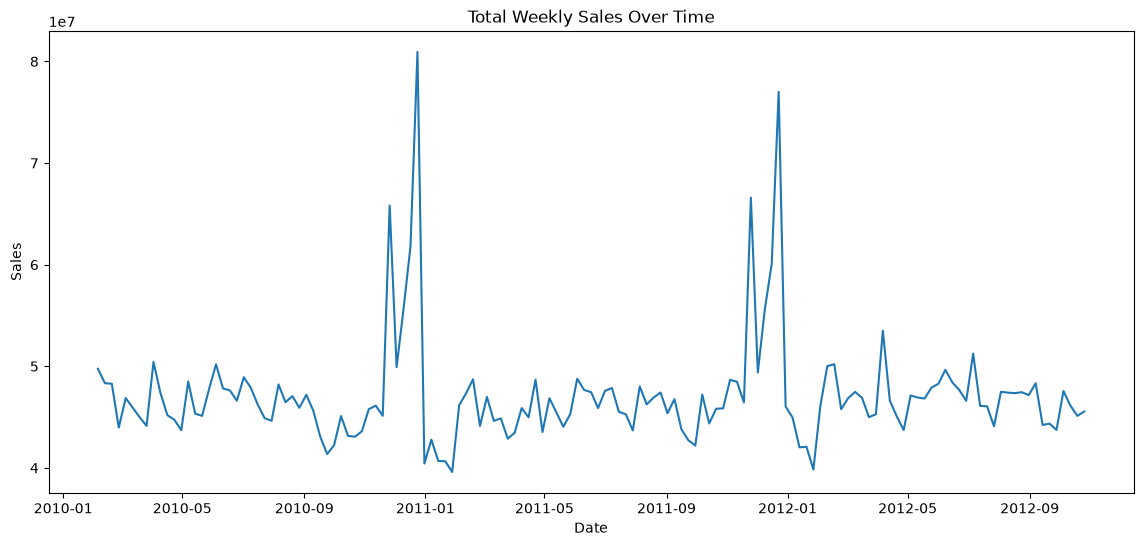

In [30]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [31]:
store_sales = (
    train.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

In [32]:
dept_sales = (
    train.groupby("Dept")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

dept_sales.head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

In [40]:
train_df = pd.merge(
    train,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

In [41]:
train_df = pd.merge(
    train_df,
    stores,
    on="Store",
    how="left"
)

In [42]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [43]:
train_df.shape

(421570, 16)

In [44]:
train_df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [45]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

In [46]:
train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Week"] = train_df["Date"].dt.isocalendar().week
train_df["Day"] = train_df["Date"].dt.day
train_df["DayOfWeek"] = train_df["Date"].dt.dayofweek
train_df["Quarter"] = train_df["Date"].dt.quarter

In [47]:
train_df[
    ["Date","Year","Month","Week","Day","DayOfWeek","Quarter"]
].head()

,Date,Year,Month,Week,Day,DayOfWeek,Quarter
0,2010-02-05,2010,2,5,5,4,1
1,2010-02-12,2010,2,6,12,4,1
2,2010-02-19,2010,2,7,19,4,1
3,2010-02-26,2010,2,8,26,4,1
4,2010-03-05,2010,3,9,5,4,1


In [48]:
train_df["Type"].value_counts()

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

In [49]:
train_df["Size"].describe()

count    421570.000000
mean     136727.915739
std       60980.583328
min       34875.000000
25%       93638.000000
50%      140167.000000
75%      202505.000000
max      219622.000000
Name: Size, dtype: float64

In [50]:
train_df.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [51]:
train_df.isnull().sum().sort_values(ascending=False)

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Temperature          0
IsHoliday            0
Weekly_Sales         0
Date                 0
Dept                 0
Fuel_Price           0
CPI                  0
Unemployment         0
Type                 0
Size                 0
Year                 0
Month                0
Week                 0
Day                  0
DayOfWeek            0
Quarter              0
dtype: int64

In [52]:
missing = (
    train_df.isnull().sum()
    / len(train_df)
    * 100
).sort_values(ascending=False)

missing

MarkDown2       73.611025
MarkDown4       67.984676
MarkDown3       67.480845
MarkDown1       64.257181
MarkDown5       64.079038
Store            0.000000
Temperature      0.000000
IsHoliday        0.000000
Weekly_Sales     0.000000
Date             0.000000
Dept             0.000000
Fuel_Price       0.000000
CPI              0.000000
Unemployment     0.000000
Type             0.000000
Size             0.000000
Year             0.000000
Month            0.000000
Week             0.000000
Day              0.000000
DayOfWeek        0.000000
Quarter          0.000000
dtype: float64

In [53]:
train_df[
    train_df["MarkDown1"].isnull()
].head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,CPI,Unemployment,Type,Size,Year,Month,Week,Day,DayOfWeek,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,211.096358,8.106,A,151315,2010,2,5,5,4,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,211.242170,8.106,A,151315,2010,2,6,12,4,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,211.289143,8.106,A,151315,2010,2,7,19,4,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,211.319643,8.106,A,151315,2010,2,8,26,4,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,211.350143,8.106,A,151315,2010,3,9,5,4,1


In [54]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_df[markdown_cols] = train_df[markdown_cols].fillna(0)

In [55]:
train_df.isnull().sum().sort_values(ascending=False)

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
Year            0
Month           0
Week            0
Day             0
DayOfWeek       0
Quarter         0
dtype: int64

In [56]:
train_df.duplicated().sum()

np.int64(0)

In [57]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

In [58]:
train_df = train_df.sort_values(
    ["Store", "Dept", "Date"]
)

In [59]:
train_df["Lag_1"] = (
    train_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
)

In [60]:
train_df["Lag_2"] = (
    train_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(2)
)

In [61]:
train_df["Lag_4"] = (
    train_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(4)
)

In [62]:
sample = train_df[
    (train_df["Store"] == 1)
    &
    (train_df["Dept"] == 1)
]

sample[
    [
        "Date",
        "Weekly_Sales",
        "Lag_1",
        "Lag_2",
        "Lag_4"
    ]
].head(10)

,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4
0,2010-02-05,24924.50,NaN,NaN,NaN
1,2010-02-12,46039.49,24924.50,NaN,NaN
2,2010-02-19,41595.55,46039.49,24924.50,NaN
3,2010-02-26,19403.54,41595.55,46039.49,NaN
4,2010-03-05,21827.90,19403.54,41595.55,24924.50
5,2010-03-12,21043.39,21827.90,19403.54,46039.49
6,2010-03-19,22136.64,21043.39,21827.90,41595.55
7,2010-03-26,26229.21,22136.64,21043.39,19403.54
8,2010-04-02,57258.43,26229.21,22136.64,21827.90
9,2010-04-09,42960.91,57258.43,26229.21,21043.39


In [63]:
train_df["Rolling_Mean_4"] = (
    train_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(
        lambda x:
        x.shift(1).rolling(4).mean()
    )
)

In [64]:
train_df[
    [
        "Weekly_Sales",
        "Lag_1",
        "Rolling_Mean_4"
    ]
].head(15)

,Weekly_Sales,Lag_1,Rolling_Mean_4
0,24924.50,NaN,NaN
1,46039.49,24924.50,NaN
2,41595.55,46039.49,NaN
3,19403.54,41595.55,NaN
4,21827.90,19403.54,32990.7700
5,21043.39,21827.90,32216.6200
6,22136.64,21043.39,25967.5950
7,26229.21,22136.64,21102.8675
8,57258.43,26229.21,22809.2850
9,42960.91,57258.43,31666.9175


In [65]:
feature_cols = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "DayOfWeek",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4"
]

In [66]:
X = train_df[feature_cols]
y = train_df["Weekly_Sales"]

In [67]:
model_data = train_df.dropna(subset=feature_cols + ["Weekly_Sales"])

In [68]:
X = model_data[feature_cols]
y = model_data["Weekly_Sales"]

In [69]:
train_data = model_data[model_data["Year"] < 2012]
test_data = model_data[model_data["Year"] == 2012]

X_train = train_data[feature_cols]
y_train = train_data["Weekly_Sales"]

X_test = test_data[feature_cols]
y_test = test_data["Weekly_Sales"]

In [70]:
print(X_train.shape)
print(X_test.shape)

(281140, 17)
(127296, 17)


In [71]:
print(train_data["Date"].min(), train_data["Date"].max())
print(test_data["Date"].min(), test_data["Date"].max())

2010-03-05 00:00:00 2011-12-30 00:00:00
2012-01-06 00:00:00 2012-10-26 00:00:00


In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
lr_model = LinearRegression()

In [74]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ -2.82, 0.73,-200. ,..., 0.08, 0.2 , 0.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['Store','Dept','IsHoliday',...,'Lag_2','Lag_4','Rolling_Mean_4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.333e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [75]:
lr_predictions = lr_model.predict(X_test)

In [76]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

comparison.head(10)

,Actual,Predicted
0,16567.69,31508.273920
1,16894.40,28355.770827
2,18365.10,24946.931428
3,18378.16,17668.269009
4,23510.49,16548.937628
5,36988.49,18575.781401
6,54060.10,25391.295002
7,20124.22,34887.295870
8,20113.03,28469.027796
9,21140.07,27908.160789


In [82]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, lr_predictions)
rmse = root_mean_squared_error(y_test, lr_predictions)
mape = mean_absolute_percentage_error(y_test, lr_predictions)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2%}")

MAE  : 1999.45
RMSE : 4400.12
MAPE : 33769515788840592.00%


In [88]:
(y_test == 0).sum()

np.int64(18)

In [89]:
y_test.min()

np.float64(-1699.0)

In [85]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, lr_predictions)

print(f"R² Score : {r2:.4f}")

R² Score : 0.9605


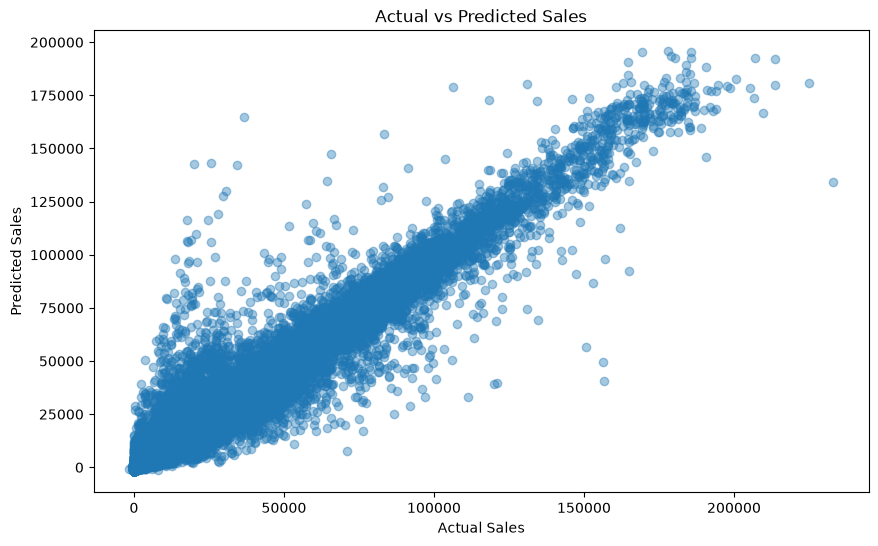

In [90]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.4
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [91]:
from sklearn.ensemble import RandomForestRegressor

In [92]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [93]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [94]:
rf_predictions = rf_model.predict(X_test)

In [95]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = root_mean_squared_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1564.51
RMSE: 3416.80
R²  : 0.9762


In [96]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,Lag_1,0.737118
16,Rolling_Mean_4,0.185548
15,Lag_4,0.023148
10,Week,0.013568
14,Lag_2,0.010372
1,Dept,0.007323
6,Unemployment,0.003514
2,IsHoliday,0.003457
3,Temperature,0.003335
4,Fuel_Price,0.003226


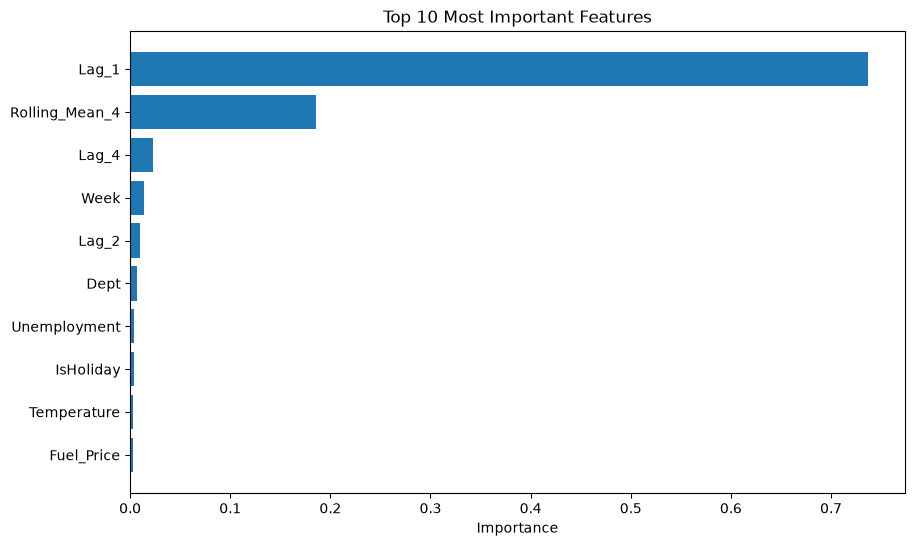

In [97]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [101]:
from xgboost import XGBRegressor

In [102]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [103]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [104]:
xgb_predictions = xgb_model.predict(X_test)

In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = root_mean_squared_error(y_test, xgb_predictions)
r2 = r2_score(y_test, xgb_predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1498.40
RMSE: 3271.33
R²  : 0.9781


In [106]:
import joblib

In [107]:
joblib.dump(
    xgb_model,
    "../models/xgboost_sales_forecast.pkl"
)

['../models/xgboost_sales_forecast.pkl']

In [108]:
loaded_model = joblib.load(
    "../models/xgboost_sales_forecast.pkl"
)

In [109]:
loaded_predictions = loaded_model.predict(X_test)

In [110]:
loaded_predictions[:5]

array([21421.871, 17417.51 , 18349.887, 20067.98 , 22526.816],
      dtype=float32)

In [111]:
xgb_predictions[:5]

array([21421.871, 17417.51 , 18349.887, 20067.98 , 22526.816],
      dtype=float32)

In [112]:
feature_cols

['Store',
 'Dept',
 'IsHoliday',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Size',
 'Year',
 'Month',
 'Week',
 'Quarter',
 'DayOfWeek',
 'Lag_1',
 'Lag_2',
 'Lag_4',
 'Rolling_Mean_4']

In [113]:
artifacts = {
    "model": xgb_model,
    "features": feature_cols
}

In [114]:
joblib.dump(
    artifacts,
    "../models/forecasting_pipeline.pkl"
)

['../models/forecasting_pipeline.pkl']